First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Dataset Shape:
(418, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing Values:
PassengerId  

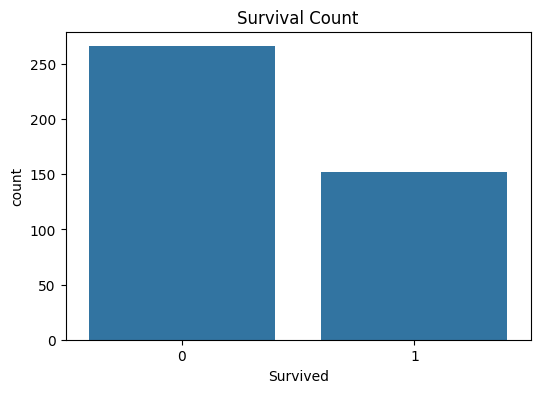

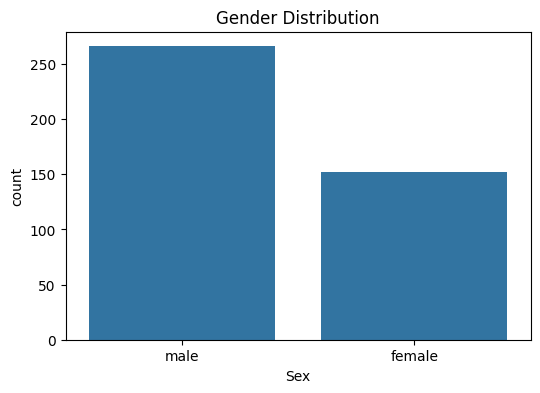

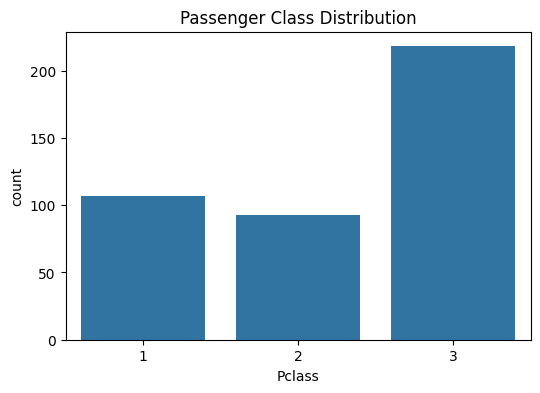

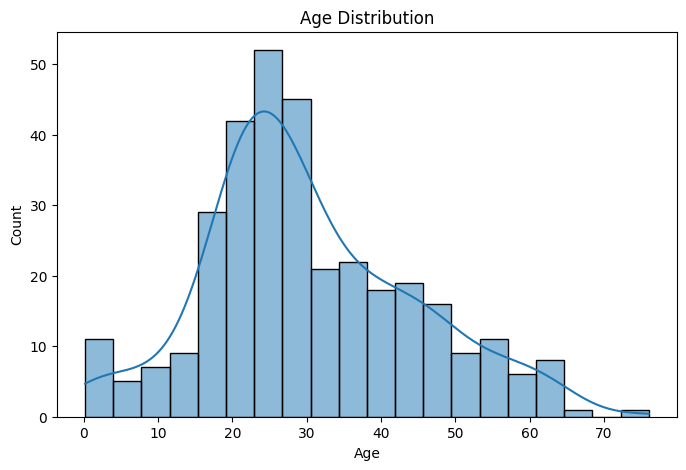

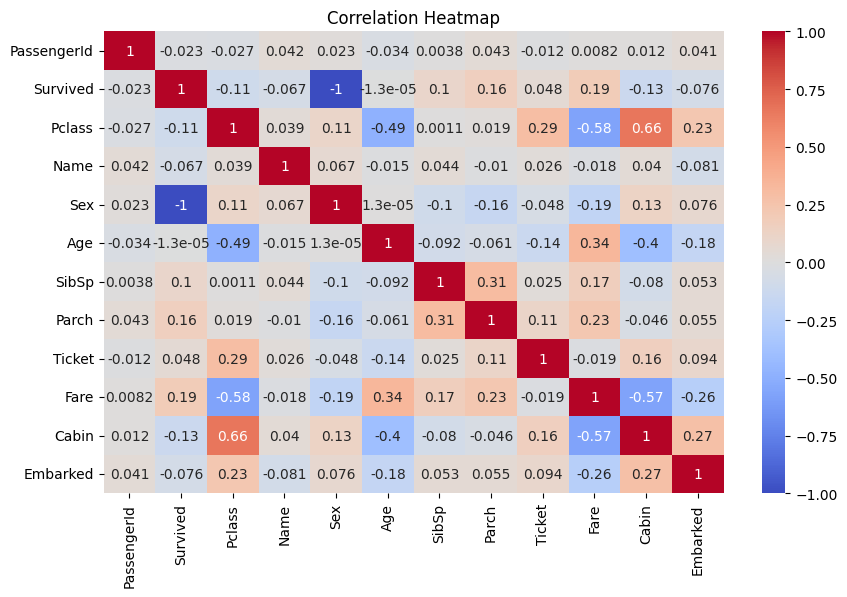

Training Data Shape: (334, 7)
Testing Data Shape: (84, 7)


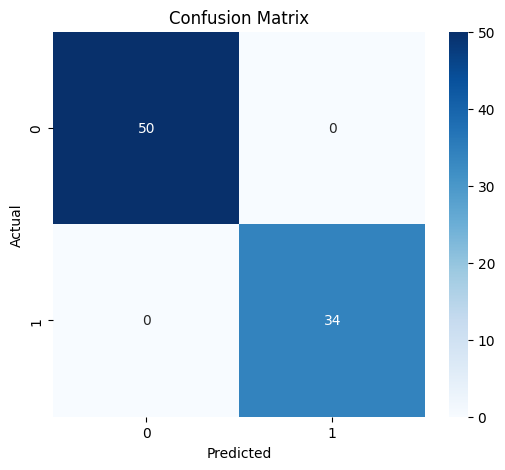


===== Model Evaluation =====
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        50
         1.0       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84


Sample Predictions:


,Actual,Predicted
321,0.0,0.0
324,1.0,1.0
388,0.0,0.0
56,0.0,0.0
153,1.0,1.0
30,0.0,0.0
72,1.0,1.0
82,0.0,0.0
258,1.0,1.0
416,0.0,0.0


In [1]:
# ============================================
# Binary Classification Project (Kaggle Notebook)
# Dataset: tested.csv
# ============================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv('/kaggle/input/datasets/brendan45774/test-file/tested.csv')

# If running locally in notebook uploads:
# df = pd.read_csv('tested.csv')

# -----------------------------
# 3. Display Dataset
# -----------------------------
print("First 5 Rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# 4. EDA (Exploratory Data Analysis)
# -----------------------------

# Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

# Passenger Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))

# Convert categorical columns temporarily
temp_df = df.copy()

for col in temp_df.select_dtypes(include='object').columns:
    temp_df[col] = LabelEncoder().fit_transform(temp_df[col].astype(str))

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 5. Data Preprocessing
# -----------------------------

# Drop unnecessary columns
drop_columns = ['PassengerId', 'Name', 'Ticket', 'Cabin']

for col in drop_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Handle Missing Values
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

# Numeric Missing Values
num_imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = num_imputer.fit_transform(df[numeric_columns])

# Categorical Missing Values
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = cat_imputer.fit_transform(df[categorical_columns])

# Encode Categorical Columns
encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# -----------------------------
# 6. Define Features and Target
# -----------------------------
X = df.drop('Survived', axis=1)
y = df['Survived']

# -----------------------------
# 7. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# -----------------------------
# 8. Train Logistic Regression Model
# -----------------------------
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# -----------------------------
# 9. Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# 10. Evaluation
# -----------------------------

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("\n===== Model Evaluation =====")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 11. Sample Predictions
# -----------------------------
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nSample Predictions:")
display(results.head(10))